# Analisis de expresion diferencial
Jupiter para hacer las pruebas del uso de pydeseq dos a partir de una matriz de conteos generada previamente mediante coveraebed, salmon o kalisto 

In [11]:
# Cargando los modulos de pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.preprocessing import deseq2_norm
import pandas as pd
import numpy as np
import os 
import seaborn as sns 
import matplotlib.pyplot as plt 

#cargar la matriz de conteos 
count_matrix= pd.read_csv("../../results/babesia/count_matrix_clean.tsv", sep="\t", index_col=0)

print(f"Genes en la matriz original previo al filtro {count_matrix.shape[0]}")

#filtrado mediante conteos por millon 

df_CountFilter= count_matrix[(((count_matrix/count_matrix.sum())*1e6) >= 5).sum(axis=1) >= 3] 

print(f"Genes en la matriz filtrada mediante conteos por melon\nAl menos 5 conteos por millon y representación en 3 columnas\n {df_CountFilter.shape[0]}") 

#cargar la matriz de diseño 
dess_matrix= pd.read_csv("../../results/babesia/design_matrix.tsv", sep="\t", index_col=0) 


metadata_df=dess_matrix.drop("batch",axis=1,inplace=False)

#dess_matrix.drop(["Merozoite_3","IntraEri_3"], axis=0, inplace=True)

display(dess_matrix) 
display(metadata_df)
#df_CountFilter.drop(["Merozoite_3","IntraEri_3"], axis=1, inplace=True)
display(df_CountFilter)

Genes en la matriz original previo al filtro 4078
Genes en la matriz filtrada mediante conteos por melon
Al menos 5 conteos por millon y representación en 3 columnas
 3682


,condition,batch
Merozoite_1,Merozoite,1
Merozoite_2,Merozoite,1
Merozoite_3,Merozoite,2
IntraEri_1,IntraEri,1
IntraEri_2,IntraEri,1
IntraEri_3,IntraEri,2


,condition
Merozoite_1,Merozoite
Merozoite_2,Merozoite
Merozoite_3,Merozoite
IntraEri_1,IntraEri
IntraEri_2,IntraEri
IntraEri_3,IntraEri


,Merozoite_1,Merozoite_2,Merozoite_3,IntraEri_1,IntraEri_2,IntraEri_3
g1,1294,783,2876,1173,1353,12532
g10,70,69,303,35,35,357
g100,97,81,432,117,109,1000
g1000,80,98,426,88,90,724
g1001,105,154,614,124,169,1271
...,...,...,...,...,...,...
g995,377,465,1506,387,510,4452
g996,147,181,584,117,128,1103
g997,146,145,462,121,131,1206
g998,148,147,474,122,131,1221


Ahora continuamos con la creacion de los objetos dseq

In [3]:
#Primero se crea el objto DeseqData con la información de ambas matrices
dds = DeseqDataSet(
    counts = df_CountFilter.T,
    metadata = metadata_df, 
)


# Aplicar el método deseq2 a los datos
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.75 seconds.

Fitting dispersion trend curve...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 0.72 seconds.

Fitting LFCs...
... done in 0.67 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [4]:
# Solicitando la información de las muestras
print("***** Información de las muestras *****")
print(dds.obs)

# Solicitando la información de la dispersión
print("***** Información de la dispersión *****")
print(dds.var["dispersions"])

# Solicitando los valores de cambio LFC
print("***** Información de LFC *****")
print(dds.varm["LFC"])

***** Información de las muestras *****
             condition  size_factors  replaceable
Merozoite_1  Merozoite      0.503087        False
Merozoite_2  Merozoite      0.620986        False
Merozoite_3  Merozoite      1.968399        False
IntraEri_1    IntraEri      0.504014        False
IntraEri_2    IntraEri      0.609144        False
IntraEri_3    IntraEri      5.176576        False
***** Información de la dispersión *****
g1       0.031560
g10      0.038157
g100     0.034150
g1000    0.029951
g1001    0.023660
           ...   
g995     0.007767
g996     0.014416
g997     0.018111
g998     0.017913
g999     0.095362
Name: dispersions, Length: 3682, dtype: float64
***** Información de LFC *****
       Intercept  condition[T.Merozoite]
g1      7.750940               -0.277323
g10     4.186106                0.725365
g100    5.300847               -0.092726
g1000   5.026568                0.168364
g1001   5.543937                0.016264
...          ...                     ...
g995 

In [5]:
#analizis estadistico de los datos de expresion 

# Creando el objeto de tipo DeseqStats IntraEri
ds = DeseqStats(dds, contrast=["condition", "Merozoite","IntraEri"]) 

ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition Merozoite vs IntraEri
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
g1     2043.912485       -0.400093  0.211437 -1.892256  0.058457  0.157410
g10     100.008583        1.046481  0.266667  3.924298  0.000087  0.001078
g100    191.161493       -0.133775  0.237713 -0.562761  0.573598  0.734275
g1000   165.909793        0.242899  0.227752  1.066503  0.286196  0.472840
g1001   256.270877        0.023465  0.198880  0.117983  0.906081  0.951307
...            ...             ...       ...       ...       ...       ...
g995    788.062594       -0.127809  0.113942 -1.121703  0.261989  0.448340
g996    255.949728        0.433515  0.163186  2.656569  0.007894  0.037016
g997    241.086259        0.128137  0.179441  0.714090  0.475172  0.653498
g998    244.115293        0.143182  0.178421  0.802497  0.422265  0.607171
g999     39.913987        0.948662  0.421159  2.252503  0.024290  0.083642

[3682 rows x 6 columns]


... done in 0.99 seconds.



In [6]:
res_df_pyDESeq2 = ds.results_df

## Visualización de los datos 


In [7]:
# Definir las condiciones con los valores de corte
cond = [ (res_df_pyDESeq2["padj"] <= 0.05) & (res_df_pyDESeq2["log2FoldChange"] >= 1),(res_df_pyDESeq2["padj"] <= 0.05) & (res_df_pyDESeq2["log2FoldChange"] <= -1)]

# Definir los valores correspondientes
opc = ["UP", "DOWN"]

# Crear la nueva columna
res_df_pyDESeq2["Expression"] = np.select(cond, opc, default = "Non-DE")


# Desplegando el dataframe
display(res_df_pyDESeq2[res_df_pyDESeq2["Expression"]!="Non-DE"]) 

res_df_pyDESeq2["Expression"].value_counts()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Expression
g10,100.008583,1.046481,0.266667,3.924298,8.698288e-05,1.078061e-03,UP
g108,103.801617,1.041953,0.312340,3.335954,8.500710e-04,6.629473e-03,UP
g1085,482.471645,1.166155,0.228229,5.109582,3.228726e-07,1.015807e-05,UP
g1139,72.007584,1.167702,0.338784,3.446741,5.673928e-04,4.801317e-03,UP
g1144,192.767660,1.501884,0.323247,4.646249,3.380250e-06,7.308001e-05,UP
...,...,...,...,...,...,...,...
g731,64.769212,1.609235,0.339394,4.741493,2.121485e-06,5.019839e-05,UP
g824,57.393081,1.235740,0.342985,3.602896,3.146911e-04,2.985510e-03,UP
g845,1149.493316,-1.138085,0.127784,-8.906346,5.274214e-19,6.471460e-16,DOWN
g954,584.307579,1.061407,0.214556,4.946985,7.537168e-07,2.048626e-05,UP


Expression
Non-DE    3600
UP          80
DOWN         2
Name: count, dtype: int64

## Ejemplo lectura matriz de conteos

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,log10Neg,Expression
g1,2043.912485,-0.400093,0.211437,-1.892256,0.058457,0.157410,0.802967,Non-DE
g10,100.008583,1.046481,0.266667,3.924298,0.000087,0.001078,2.967357,UP
g100,191.161493,-0.133775,0.237713,-0.562761,0.573598,0.734275,0.134141,Non-DE
g1000,165.909793,0.242899,0.227752,1.066503,0.286196,0.472840,0.325285,Non-DE
g1001,256.270877,0.023465,0.198880,0.117983,0.906081,0.951307,0.021679,Non-DE
...,...,...,...,...,...,...,...,...
g995,788.062594,-0.127809,0.113942,-1.121703,0.261989,0.448340,0.348392,Non-DE
g996,255.949728,0.433515,0.163186,2.656569,0.007894,0.037016,1.431605,Non-DE
g997,241.086259,0.128137,0.179441,0.714090,0.475172,0.653498,0.184756,Non-DE
g998,244.115293,0.143182,0.178421,0.802497,0.422265,0.607171,0.216689,Non-DE


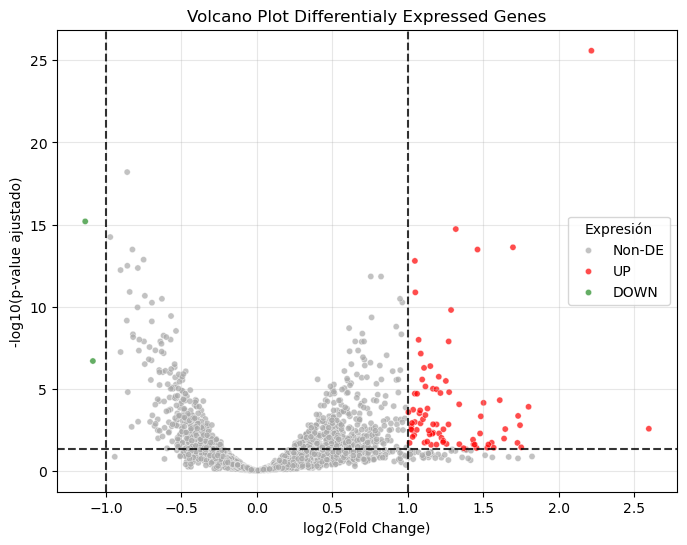

In [12]:
df_DE_matrix=pd.read_csv("../../results/babesia/DE_matrix.tsv", sep="\t", header=0, index_col=0) 
pval_threshold=0.05
lfc_threshold=1
colors = {"UP": "red", "DOWN": "forestgreen", "Non-DE": "darkgray"} 
figsize=(8, 6)


plot_df = df_DE_matrix.copy() 

plot_df['log10Neg'] = -np.log10(plot_df['padj'].clip(lower=1e-300)) # 1e-300 for every value under treshold
        
        # Defining expression categories
conditions = [
    (plot_df['padj'] < pval_threshold) & (plot_df['log2FoldChange'] > lfc_threshold), # UP
    (plot_df['padj'] < pval_threshold) & (plot_df['log2FoldChange'] < -lfc_threshold), # DOWN
    (~((plot_df['padj'] < pval_threshold) & (plot_df['log2FoldChange'].abs() > lfc_threshold))) # Non-DE
]
exp_type = ['UP', 'DOWN', 'Non-DE']
plot_df['Expression'] = np.select(conditions, exp_type, default='Non-DE') # vectorized elif

display(plot_df)

# Figure
fig, ax = plt.subplots(figsize=figsize)
        
# Create scatter plot
sns.scatterplot(data=plot_df, x='log2FoldChange', y='log10Neg', hue='Expression', palette=colors, ax=ax, s=20, alpha=0.7)
        
# Add treshold lines
ax.axhline(-np.log10(pval_threshold), color='black', linestyle='--', alpha=0.8)
ax.axvline(lfc_threshold, color='black', linestyle='--', alpha=0.8)
ax.axvline(-lfc_threshold, color='black', linestyle='--', alpha=0.8)
        
# Title and label configuration
ax.set_xlabel('log2(Fold Change)')
ax.set_ylabel('-log10(p-value ajustado)')
ax.set_title('Volcano Plot Differentialy Expressed Genes')
ax.grid(True, alpha=0.3)
ax.legend(title='Expresión') 

plt.show()